# Imports

In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics as mt

# Dataset

In [202]:
# Carregando dados de treinamento/classificação
X_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/X_training.csv')
y_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/y_training.csv')

In [203]:
# Carregando dados de validação/classificação
X_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/X_validation.csv')
y_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/y_validation.csv')

In [204]:
# Carregando dados de teste/Classificação
X_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/X_test.csv')
y_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/y_test.csv')


# Traning

### knn

In [205]:
## Modelo treinado e validado com o dataset de Treinamento
values_knn = [i for i in range(1,50)]
val_scores_knn = list()

for i in values_knn:
    model_knn = KNeighborsClassifier(n_neighbors=i)
    model_knn.fit(X_train, y_train)

    yhat_val_knn = model_knn.predict(X_val)
    acc_val_knn = mt.accuracy_score(y_val, yhat_val_knn)
    val_scores_knn.append(acc_val_knn)

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWa

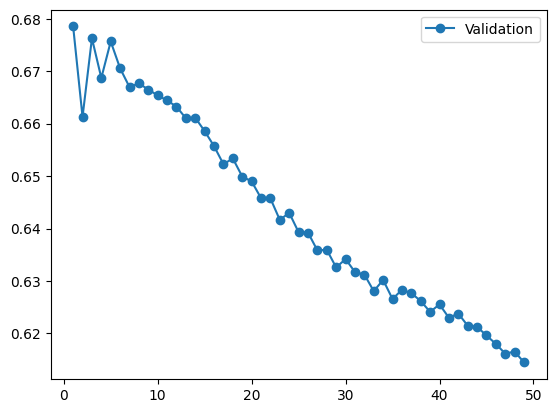

In [206]:
## plot of train and test scores vs tree depth
plt.plot( values_knn, val_scores_knn, '-o', label='Validation' )
plt.legend()
plt.show()

In [207]:
## Previsão sobre os dados de validacao
yhat_val_knn = model_knn.predict( X_val )
acc_val_knn = mt.accuracy_score( y_val, yhat_val_knn )
print( "Accuracy Over Validation: {}".format( acc_val_knn ) )

Accuracy Over Validation: 0.6144663599214903


In [208]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_knn = val_scores_knn.index( max( val_scores_knn ) )
model_last_knn = KNeighborsClassifier(n_neighbors=values_knn[max_index_knn])
model_last_knn.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [209]:
max_index_knn

0

In [210]:
## Previsão sobre os dados de test
yhat_test_knn = model_last_knn.predict( X_test )
acc_test_knn = mt.accuracy_score( y_test, yhat_test_knn )
precision_knn = mt.precision_score(y_test, yhat_test_knn)
recall_knn = mt.recall_score(y_test, yhat_test_knn)
f1_score_knn = mt.f1_score(y_test, yhat_test_knn)

print(f"F1 Score: {f1_score_knn}")
print(f"Precision: {precision_knn}")
print(f"Recall: {recall_knn}")
print( "Accuracy Over Test: {}".format( acc_test_knn ) )

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


F1 Score: 0.6597794342007759
Precision: 0.6537664132688321
Recall: 0.665904091509019
Accuracy Over Test: 0.6985671803190051


### Decision Tree

In [211]:
## Modelo treinado e validado com o dataset de Treinamento
values_dt = [i for i in range(1,50)]
val_scores_dt = list()

for i in values_dt:
    model_dt = DecisionTreeClassifier(max_depth=i)
    model_dt.fit(X_train, y_train)

    yhat_val_dt = model_dt.predict(X_val)
    acc_val_dt = mt.accuracy_score(y_val, yhat_val_dt)
    val_scores_dt.append(acc_val_dt)

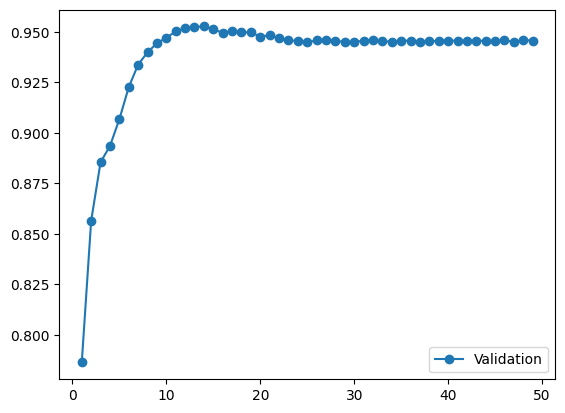

In [212]:
## plot of train and test scores vs tree depth
plt.plot( values_dt, val_scores_dt, '-o', label='Validation' )
plt.legend()
plt.show()

In [213]:
## Previsão sobre os dados de validacao
yhat_val_dt = model_dt.predict( X_val )
acc_val_dt = mt.accuracy_score( y_val, yhat_val_dt )
print( "Accuracy Over Validation: {}".format( acc_val_dt ) )

Accuracy Over Validation: 0.945654622092088


In [214]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_dt = val_scores_dt.index( max( val_scores_dt ) ) # Encontrar o índice do valor máximo de acurácia na lista de acurácias de validação
model_last_dt = DecisionTreeClassifier(max_depth=values_dt[max_index_dt])
model_last_dt.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [215]:
## Previsão sobre os dados de test
yhat_test_dt = model_last_dt.predict( X_test )
acc_test_dt = mt.accuracy_score( y_test, yhat_test_dt )
precision_dt = mt.precision_score(y_test, yhat_test_dt)
recall_dt = mt.recall_score(y_test, yhat_test_dt)
f1_score_dt = mt.f1_score(y_test, yhat_test_dt)

print(f"F1 Score: {f1_score_dt}")
print(f"Precision: {precision_dt}")
print(f"Recall: {recall_dt}")
print( "Accuracy Over Test: {}".format( acc_test_dt ) )

F1 Score: 0.9502527267890396
Precision: 0.95772633836804
Recall: 0.9428948526176859
Accuracy Over Test: 0.956667825280964


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


### Random Forest

In [216]:
## Modelo treinado e validado com o dataset de Treinamento
values_rf = [i for i in range(1,50)]
val_scores_rf = list()

for i in values_rf:
    model_rf = RandomForestClassifier(n_estimators=i)
    model_rf.fit(X_train, y_train)

    yhat_val_rf = model_rf.predict(X_val)
    acc_val_rf = mt.accuracy_score(y_val, yhat_val_rf)
    val_scores_rf.append(acc_val_rf)

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A co

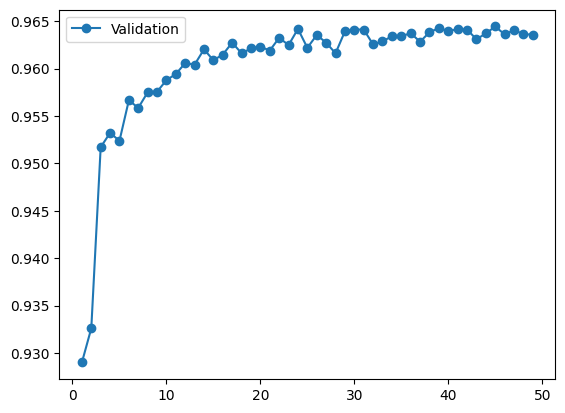

In [217]:
## plot of train and test scores vs tree depth
plt.plot( values_rf, val_scores_rf, '-o', label='Validation' )
plt.legend()
plt.show()

In [218]:
## Previsão sobre os dados de validacao
yhat_val_rf = model_rf.predict( X_val )
acc_val_rf = mt.accuracy_score( y_val, yhat_val_rf )
print( "Accuracy Over Validation: {}".format( acc_val_rf ) )

Accuracy Over Validation: 0.9635766916567458


In [219]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_rf = val_scores_rf.index( max( val_scores_rf ) ) # Encontrar o índice do valor máximo de acurácia na lista de acurácias de validação
model_last_rf = RandomForestClassifier(n_estimators=values_rf[max_index_rf])
model_last_rf.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",45
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [220]:
## Previsão sobre os dados de test
yhat_test_rf = model_last_rf.predict( X_test )
acc_test_rf = mt.accuracy_score( y_test, yhat_test_rf )
precision_rf = mt.precision_score(y_test, yhat_test_rf)
recall_rf = mt.recall_score(y_test, yhat_test_rf)
f1_score_rf = mt.f1_score(y_test, yhat_test_rf)

print(f"F1 Score: {f1_score_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print( "Accuracy Over Test: {}".format( acc_test_rf ) )

F1 Score: 0.9588258910648169
Precision: 0.9724031849439015
Recall: 0.9456225252969643
Accuracy Over Test: 0.9643533001197234


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


### Logistic Regressor

# Performance

# Resultados

In [221]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de teste
resultados_test = pd.DataFrame(columns=['Nome_do_algoritmo', 'Acurácia', 'Precision', 'Recall', 'F1_score'])

# adicionar os resultados do KNN à tabela
resultados_test.loc[0] = ['KNN',  acc_test_knn, precision_knn, recall_knn, f1_score_knn]
resultados_test.loc[1] = ['Decision Tree', acc_test_dt, precision_dt, recall_dt, f1_score_dt]
resultados_test.loc[2] = ['Random Forest', acc_test_rf, precision_rf, recall_rf, f1_score_rf]

resultados_test = resultados_test.reset_index(drop=True)
resultados_test


,Nome_do_algoritmo,Acurácia,Precision,Recall,F1_score
0,KNN,0.698567,0.653766,0.665904,0.659779
1,Decision Tree,0.956668,0.957726,0.942895,0.950253
2,Random Forest,0.964353,0.972403,0.945623,0.958826


In [ ]:
print(X_train.shape)
print(X_train.columns)
print(X_train.info())

(72515, 25)
Index(['id', 'customer_type', 'age', 'class', 'flight_distance',
       'inflight_wifi_service', 'departure_arrival_time_convenient',
       'ease_of_online_booking', 'gate_location', 'food_and_drink',
       'online_boarding', 'seat_comfort', 'inflight_entertainment',
       'on_board_service', 'leg_room_service', 'baggage_handling',
       'checkin_service', 'inflight_service', 'cleanliness',
       'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'gender_Female', 'gender_Male', 'type_of_travel_business_travel',
       'type_of_travel_personal_travel'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 72515 entries, 0 to 72514
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 72515 non-null  int64  
 1   customer_type                      72515 non-null  int64  
 2   age                             

In [239]:
y_train.head()

,0
0,1
1,1
2,0
3,0
4,0
